<a href="https://colab.research.google.com/github/devidrees/DA-Python-AUG/blob/main/Ecommerce_Sales_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color: #add8e6; padding: 10px; height: 70px; border-radius: 15px;">
    <div style="font-family: 'Georgia', serif; font-size: 20px; padding: 10px; text-align: center; position: absolute; right: 20px;color: #0a0a0a; ">
        Mohammad Idrees Bhat <br>
        <span style="font-family: 'Arial', sans-serif;font-size: 12px; color: #0a0a0a;">Tech Skills Trainer | AI/ML Consultant</span> <!--- Mohammad Idrees Bhat | Tech Skills Trainer | AI/ML Consultant --->

<div style="background-color: #002147; padding: 10px; text-align: center; color: white; font-size: 32px; font-family: 'Arial', sans-serif;">
    Ecommerce Sales Perfomance Analysis  <br>
    <h3 style="text-align: center; color: white; font-size: 15px; font-family: 'Arial', sans-serif;">  Data Cleaning & Analysis Project

**Project goal:** Explore real retail transactions, clean the data transparently, visualize meaningful patterns, and turn those patterns into evidence-based business insights.

**Dataset:** UCI Machine Learning Repository — Online Retail  
Official source: https://archive.ics.uci.edu/dataset/352/online+retail  
Citation: Chen, D. (2015). *Online Retail* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33  

### Column Information

| Column | Meaning |
|---|---|
| `InvoiceNo` | Invoice identifier; values beginning with `C` indicate a cancellation |
| `StockCode` | Product identifier |
| `Description` | Product name/description |
| `Quantity` | Number of units on a transaction line; can be negative |
| `InvoiceDate` | Date and time of the invoice |
| `UnitPrice` | Price per unit in pounds sterling |
| `CustomerID` | Customer identifier; some records have no customer ID |
| `Country` | Country associated with the customer |

The dataset contains 541,909 transaction-line records from a UK-based online giftware retailer, covering 1 December 2010 through 9 December 2011. Many customers were wholesalers.

### Questions the notebook attempts to answer:
1. How does recorded sales value change over time?
2. Which products and countries contribute most to recorded sales value?
3. How do order values vary?

### Sequence followed during the project

- Explore > Summarize > Visualize > Insights

<div style="background-color: lightgreen; color: black; padding: 4px;">
    <h3>1. Import Libraries
</h3> </div>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Set notebook visualization style
sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10


pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)

print("Libraries imported successfully!")

Libraries imported successfully!


<div style="background-color: lightgreen; color: black; padding: 4px;">
    <h3>2. Load the dataset
</h3> </div>

In [13]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

try:
    df_raw = pd.read_excel(DATA_URL)
    print("Dataset downloaded and loaded from UCI.")

except Exception as error:
    print("Automatic download failed. Upload 'Online Retail.xlsx' using the next cell.")
    print("Error:", error)

Dataset downloaded and loaded from UCI.


<div style="background-color: lightgreen; color: black; padding: 4px;">
    <h3>3. Explore the Dataset
</h3> </div>



In [23]:
print(f"The dataset has {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.\n")

# Let's check the top 5 rows
df_raw.head(2)
df_raw.sample(2)
df_raw.tail()

The dataset has 541909 rows and 8 columns.



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [22]:
# Check the columns and data types of the dataset
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [33]:
# Count distinct values for each column
unique_counts = df_raw.nunique(dropna = True).sort_values(ascending = False )
display(unique_counts)

,0
InvoiceNo,25900
InvoiceDate,23260
CustomerID,4372
Description,4223
StockCode,4070
UnitPrice,1630
Quantity,722
Country,38


- `describe()` helps understand the statistics of the dataset
  - Helps understand count, mean, min, max and percentiles of data

In [34]:
# Summary : Statistical Summary
df_raw.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


- Check Missing values
  - Inspect the number of values missing from each column
  

In [40]:
missing_summary = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(2),
    "data_type": df_raw.dtypes.astype(str)
}).sort_values(by="missing_count", ascending=False)
display(missing_summary)

,missing_count,missing_percent,data_type
CustomerID,135080,24.93,float64
Description,1454,0.27,object
StockCode,0,0.00,object
InvoiceNo,0,0.00,object
Quantity,0,0.00,int64
InvoiceDate,0,0.00,datetime64[ns]
UnitPrice,0,0.00,float64
Country,0,0.00,object


In [41]:
print("Exact duplicate rows:", df_raw.duplicated().sum())

print("Negative quantities:", (df_raw["Quantity"] < 0).sum()) # this needs to be fixed

print("Zero quantities:", (df_raw["Quantity"] == 0).sum())

print("Negative unit prices:", (df_raw["UnitPrice"] < 0).sum())

print("Zero unit prices:", (df_raw["UnitPrice"] == 0).sum()) # this can be fixed as well

print("Missing descriptions:", df_raw["Description"].isna().sum()) #

print("Missing customer IDs:", df_raw["CustomerID"].isna().sum())

Exact duplicate rows: 5268
Negative quantities: 10624
Zero quantities: 0
Negative unit prices: 2
Zero unit prices: 2515
Missing descriptions: 1454
Missing customer IDs: 135080


<div style="background-color: lightgreen; color: black; padding: 4px;">
    <h3>4. Data Cleaning
</h3> </div>

### What should we do with missing values?

- **CustomerID:** Missing IDs mean we cannot reliably connect those rows to a known customer. We will keep these rows for general sales analysis but exclude them from customer-level analysis.

- **Description:** A missing product description should not be guessed. We will label it `Unknown description` and retain the stock code.

- **Duplicates:** Remove exact duplicate rows in the analysis copy, while reporting how many were removed. Exact duplicates can occasionally be legitimate.

- **Negative quantity / cancellation invoice:** These can represent cancellations or returns. Keep them in the audit dataset, exclude them from the sales view.

- **Zero price:** May represent samples or special records. Exclude from sales value analysis, but do not erase from the data.

- Standardize column names

In [53]:
df = df_raw.copy()

# Standardize column names for easier typing in Python.
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
)

- Remove duplicates

In [54]:
# Remove exact duplicate rows and report the count.
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().copy()

print(f"Exact duplicate rows removed: {duplicates_before:,}")
print(f"Rows after duplicate removal: {len(df):,}")

Exact duplicate rows removed: 5,268
Rows after duplicate removal: 536,641


- Fix Data Types

In [60]:
# Identifiers remain text; preserve letters in invoice and product codes.
df["invoiceno"] = df["invoiceno"].astype("string").str.strip()
df["stockcode"] = df["stockcode"].astype("string").str.strip()

# Convert invoice date to datetime; unparseable values become NaT.
df["invoicedate"] = pd.to_datetime(df["invoicedate"], errors="coerce")

# Numeric conversion: invalid values become NaN, ready for audit.
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["unitprice"] = pd.to_numeric(df["unitprice"], errors="coerce")

df["customerid"] = df["customerid"].astype("string").str.strip()
df["customerid"] = pd.to_numeric(df["customerid"], errors="coerce")

# Standardize text fields.
df["description"] = df["description"].astype("string").str.strip()
df["country"] = df["country"].astype("string").str.strip()

# Preserve rows with unknown descriptions rather than deleting them.
df["description"] = df["description"].fillna("Unknown description")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    536641 non-null  string        
 1   stockcode    536641 non-null  string        
 2   description  536641 non-null  string        
 3   quantity     536641 non-null  int64         
 4   invoicedate  536641 non-null  datetime64[ns]
 5   unitprice    536641 non-null  float64       
 6   customerid   401604 non-null  Float64       
 7   country      536641 non-null  string        
dtypes: Float64(1), datetime64[ns](1), float64(1), int64(1), string(4)
memory usage: 37.4 MB


- Feature Engineering
  - We add useful columns
  - Remove less useful columns
  - We create calculated columns

In [65]:
# we are creating a new column
df["year_month"] = df["invoicedate"].dt.to_period("M").astype(str)

df["sales"] = df["quantity"] * df["unitprice"]

<div style="background-color: lightgreen; color: black; padding: 4px;">
    <h3>5. Data Visualization
</h3> </div>

### Visualization 1: Monthly recorded sales value
-  

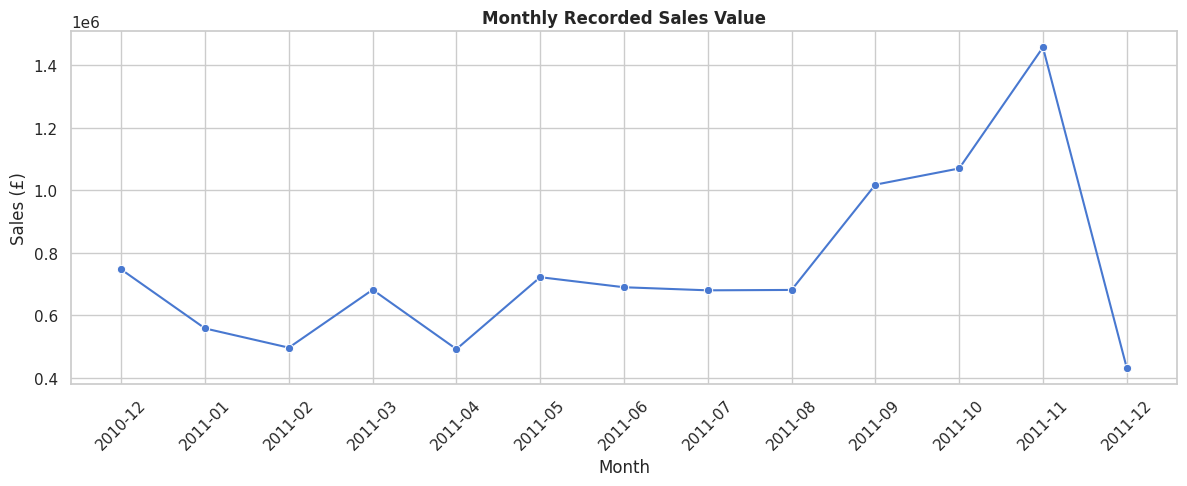

,year_month,sales
0,2010-12,746723.610
1,2011-01,558448.560
2,2011-02,497026.410
3,2011-03,682013.980
4,2011-04,492367.841
5,2011-05,722094.100
6,2011-06,689977.230
7,2011-07,680156.991
8,2011-08,681386.460
9,2011-09,1017596.682


In [66]:
monthly_sales = (
    df.groupby("year_month")["sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5)) # canvas size

sns.lineplot(data=monthly_sales, x="year_month", y="sales", marker="o")

plt.title("Monthly Recorded Sales Value")
plt.xlabel("Month")
plt.ylabel("Sales (£)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()